# Historical GP validation and uncertainty calibration

## tl;dr

- This notebook evaluates the surrogate **out of sample** using 104 rolling one-step-ahead folds: each historical return is predicted using only evidence available before that return.
- All eight functions beat a historical-mean baseline on RMSE.
- Mean negative log predictive density (NLPD) complements RMSE by scoring both predictive location and uncertainty.
- Calibration is heterogeneous. F5–F7 under-cover at the nominal 95% level, while F1 and F8 are conservative.
- Final GP hyperparameters are fitted to all verified evidence through Week 13, and kernel-bound warnings are reported as evidence rather than suppressed.
- These results assess surrogate prediction and calibration. They do not replace optimisation-performance or recommendation-robustness evaluation.


## Context & Methods

The evaluation has three distinct questions:

1. **Optimisation performance:** did submitted queries improve the best observed objective within each function?
2. **Surrogate accuracy and calibration:** did a GP trained on the historical prefix predict the next returned value, and did its intervals cover at their nominal rates?
3. **Recommendation robustness:** does the proposed point remain stable under acquisition, GP-bound, and candidate-design changes?

### Key assumptions

The Matérn-5/2 GP, target normalisation, configured bounds, and canonical ledger pairing are held fixed. Each function has thirteen rolling folds. Hyperparameters are re-estimated inside every fold with one optimiser restart; final diagnostics use all evidence through Week 13, three restarts and fixed seeds. Adaptive historical queries are not an independent random test set, so the results are conditional predictive checks rather than generalisation guarantees.


In [1]:
from pathlib import Path
import subprocess
import sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / 'Results' / 'query_output_ledger.csv').is_file():
    for candidate in Path.cwd().parents:
        if (candidate / 'Results' / 'query_output_ledger.csv').is_file():
            ROOT = candidate
            break
assert (ROOT / 'Results' / 'query_output_ledger.csv').is_file()
print(f'Repository: {ROOT}')

Repository: /Users/john-peteramewu/Documents/Codex/2026-08-22/prioritized-corrections-1-resolve-week-13/repo


## Data

### 1. Recompute rolling validation from the immutable ledger

In [2]:
subprocess.run(
    [sys.executable, str(ROOT / 'Code' / 'run_gp_validation.py')],
    cwd=ROOT,
    check=True,
)
predictions = pd.read_csv(ROOT / 'Results' / 'gp_rolling_validation_predictions.csv')
metrics = pd.read_csv(ROOT / 'Results' / 'gp_validation_metrics.csv')
hyperparameters = pd.read_csv(ROOT / 'Results' / 'gp_final_hyperparameters.csv')
assert len(predictions) == 104
assert len(metrics) == len(hyperparameters) == 8
assert predictions.groupby('function').size().eq(13).all()
print('Validated 104 rolling folds: 13 per function.')

Saved 104 rolling folds, 8 metric rows, and 8 final hyperparameter rows
Validated 104 rolling folds: 13 per function.


## Results

### 2. Surrogate accuracy and interval calibration

In [3]:
display(metrics.round({
    'mae': 6, 'rmse': 6, 'naive_mean_rmse': 6, 'rmse_skill_vs_naive': 3,
    'coverage_50': 3, 'coverage_80': 3, 'coverage_95': 3,
    'mean_abs_z': 3, 'mean_negative_log_predictive_density': 3,
    'hyperparameter_bound_hit_rate': 3,
}))

,function,dimensions,rolling_folds,mae,rmse,naive_mean_rmse,rmse_skill_vs_naive,mean_absolute_standardized_error,mean_negative_log_predictive_density,coverage_50,coverage_80,coverage_95,mean_predictive_std,mean_abs_z,hyperparameter_bound_hit_rate,convergence_warning_folds
0,1,2,13,0.000132,0.000172,0.000246,0.303,0.143161,-6.479,1.000,1.000,1.000,0.000698,0.155,0.615,8
1,2,2,13,0.107260,0.138203,0.209988,0.342,0.507342,-0.735,0.462,0.846,1.000,0.138013,0.819,0.154,2
2,3,3,13,0.020040,0.031631,0.050953,0.379,0.259429,6.173,0.385,0.769,0.923,0.027782,1.939,0.923,12
3,4,4,13,1.577977,2.327732,10.286353,0.774,0.213515,2.380,0.308,0.692,0.769,1.788117,1.180,0.462,6
4,5,4,13,323.426493,599.720417,1555.969259,0.615,0.775223,13.161,0.385,0.615,0.615,120.681302,2.497,1.000,13
5,6,5,13,0.162939,0.235192,0.614125,0.617,0.345908,-0.297,0.462,0.615,0.769,0.154278,1.066,0.154,2
6,7,6,13,0.297025,0.428498,1.055977,0.594,0.746682,1.922,0.231,0.462,0.692,0.152644,1.863,0.846,11
7,8,8,13,0.099005,0.127484,1.400150,0.909,0.096771,-0.445,0.846,1.000,1.000,0.245742,0.421,1.000,13


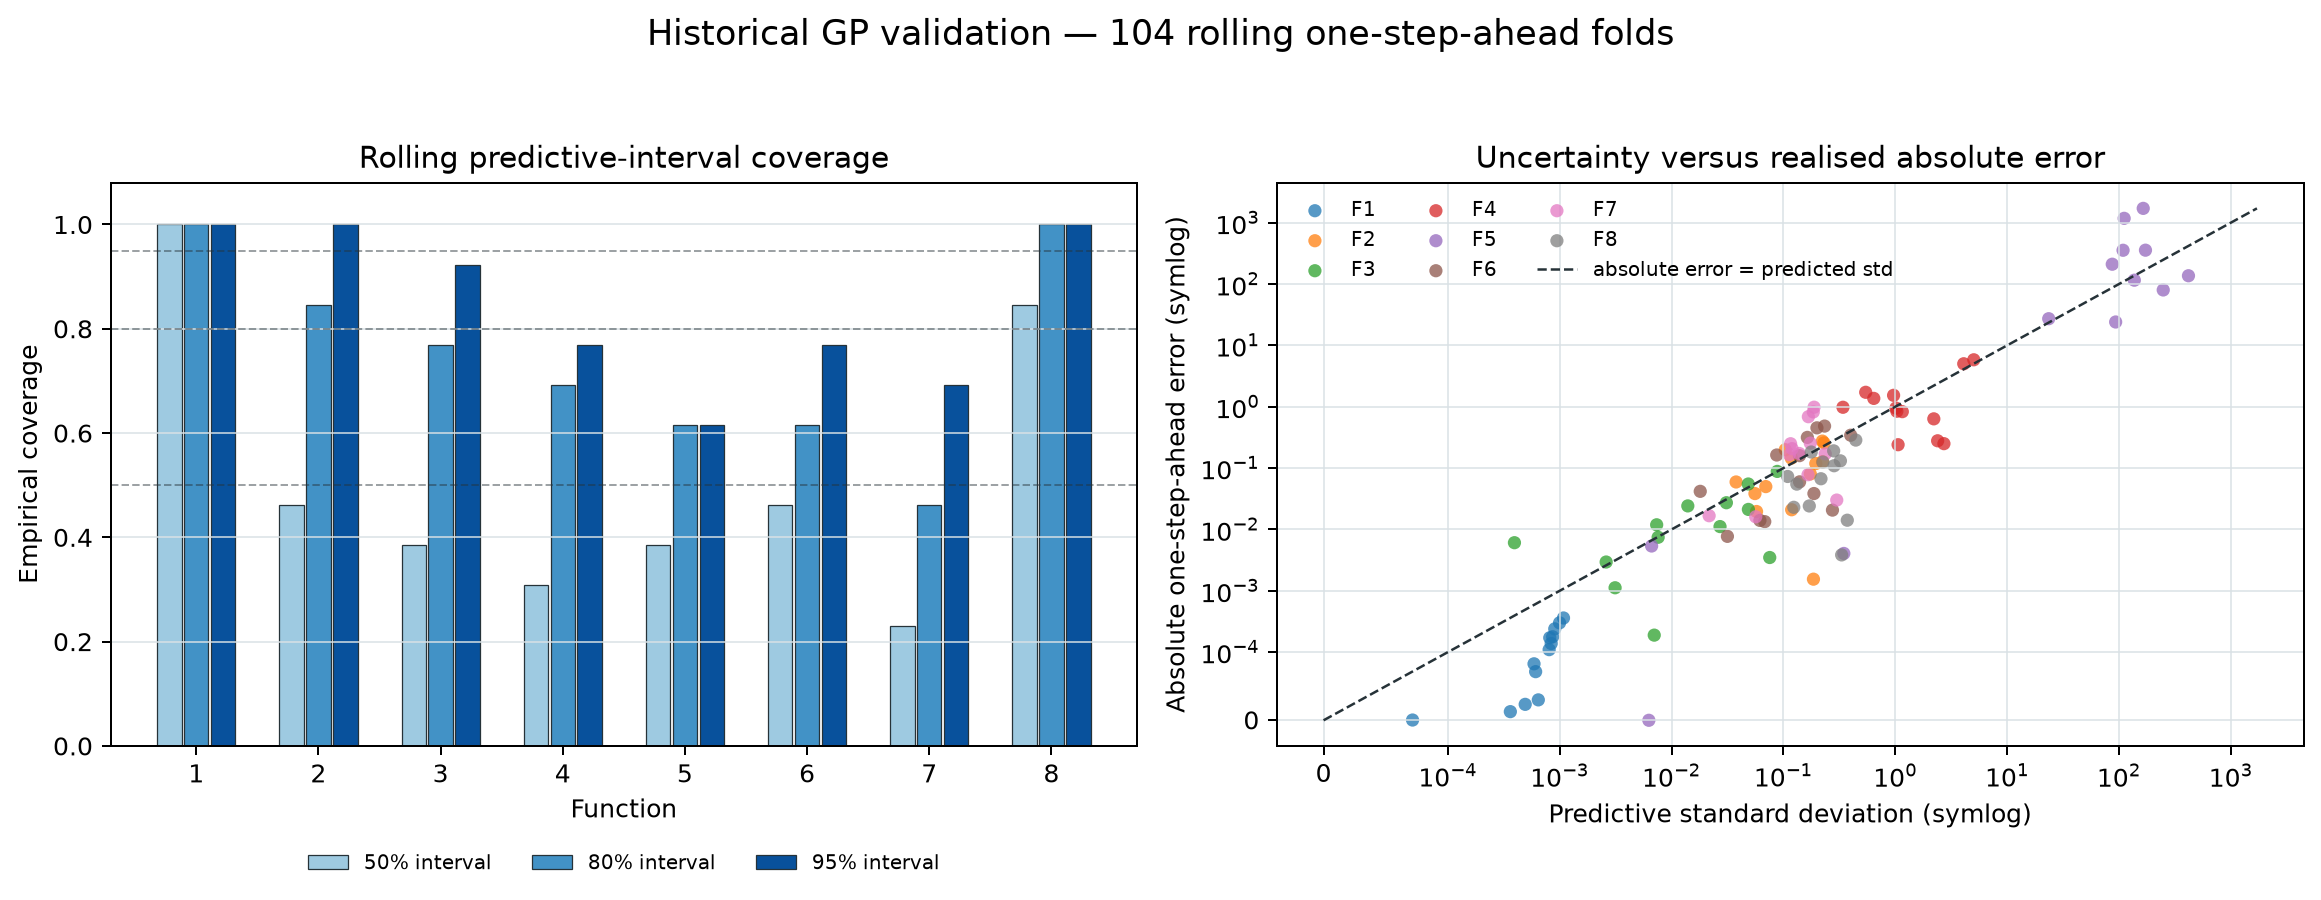

In [4]:
display(Image(filename=str(ROOT / 'Figures' / 'gp_rolling_validation_diagnostics.png')))

Coverage should be interpreted against nominal 50%, 80%, and 95% rates. With only thirteen folds per function, one fold changes coverage by 7.7 percentage points. NLPD rewards probability distributions that place high density on the realised value and penalises confident misses. The uncertainty/error panel uses symmetric-log axes because objective scales differ sharply across functions; it is not a cross-function ranking of raw errors.


### 3. Final fitted GP hyperparameters

In [5]:
columns = [
    'function', 'observation_count', 'constant_value', 'length_scales',
    'noise_level', 'constant_bound_status', 'length_scale_bound_status',
    'noise_bound_status', 'convergence_warning_count',
]
display(hyperparameters[columns])

,function,observation_count,constant_value,length_scales,noise_level,constant_bound_status,length_scale_bound_status,noise_bound_status,convergence_warning_count
0,1,23,1.378617,"[2.0,0.04455072508641234]",1.270864e-10,none,"[""upper"",""none""]",none,1
1,2,23,0.678688,"[0.04689208827843795,2.0]",1.000000e-02,none,"[""none"",""upper""]",upper,2
2,3,28,1.900802,"[2.0,1.8118948723805384,0.07871549206144186]",2.185434e-03,none,"[""upper"",""none"",""none""]",none,1
3,4,43,15.442587,"[1.8461474761679917,1.8608394549975118,1.89226...",2.038831e-03,none,"[""none"",""none"",""none"",""none""]",none,0
4,5,33,2.757505,"[2.0,0.36822751354945116,0.9152497252036473,2.0]",1.000000e-10,none,"[""upper"",""none"",""none"",""upper""]",lower,7
5,6,33,4.370918,"[1.3310717578526705,0.8741969544465577,1.17406...",1.126235e-03,none,"[""none"",""none"",""none"",""none"",""upper""]",none,1
6,7,43,0.635060,"[0.6858384115676833,0.4427759599053018,1.07200...",1.055622e-10,none,"[""none"",""none"",""none"",""none"",""none"",""none""]",none,0
7,8,53,0.926208,"[1.2450415761415656,2.0,1.0157341933918982,2.0...",1.000000e-10,none,"[""none"",""upper"",""none"",""upper"",""upper"",""upper""...",lower,6


Longer fitted length scales imply slower variation along a coordinate under this kernel; a value at the upper bound means the data support a smoother direction than the configured search permitted. Near-zero noise estimates indicate that the fitted model attributes little independent noise, not that the black box is proven noiseless. Boundary estimates and convergence warnings indicate weak identification or restrictive bounds and motivate the separate wider-bound sensitivity analysis.


## Takeaways

1. The 104-fold history includes all verified returns through Week 13; tag v1.0.8 preserves the Week 13 proposals before outcomes.
2. Rolling validation and calibration are diagnostic checks, not controlled acquisition comparisons.
3. Interval coverage and baseline skill vary by function and should be interpreted from the regenerated metric table.
4. Recommendation robustness is a separate property. The Week 13 function-specific UCB/EI/PI policy is adaptive and heuristic and was selected before Week 13 outcomes.
5. All findings are conditional on thirteen adaptive folds per function, the recovered ledger, the Matérn model family, and the frozen environment. They do not establish global optimality or independent-test-set generalisation.
